<div style="text-align: center; margin-top: 200px; margin-bottom: 100px;">

# Machine Learning for Data Analytics  
## Assignment 1  

<br><br>

**Piotr Czech, Filip Miśkiewicz**

</div>

In [1]:
%%html
<style>
img {
    max-width: 1050px !important;
    margin: 20px auto !important;
    display: block !important;
    border: 2px solid #ccc !important;
    padding: 60px 30px !important;
}
</style>

In [2]:
# standard library
import time
import timeit
import tracemalloc
import warnings
from typing import Any, Dict, List, Tuple

# data & visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

# optimization
import optuna
from optuna.samplers import RandomSampler, TPESampler
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
)

# sklearn utilities
from sklearn.base import clone
from sklearn.datasets import fetch_california_housing
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# sklearn models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge

# boosting libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# handling specific warnings
from sklearn.exceptions import ConvergenceWarning
from optuna.exceptions import ExperimentalWarning

## Table of Contents

* [Problem 1.1: Gradient Boosting Implementation](#problem-11-gradient-boosting-implementation)
* [Problem 1.2: XGBoost vs. LightGBM vs. CatBoost](#problem-12-xgboost-vs-lightgbm-vs-catboost)
* [Problem 1.3: Stacked Ensemble](#problem-13-stacked-ensemble)
* [Problem 1.4: Bayesian Optimization with Optuna](#problem-14-bayesian-optimization-with-optuna)

## Problem 1.1: Gradient Boosting Implementation

### Objective
Implement gradient boosting from scratch for regression:

### Tasks
- Use decision tree stumps as base learners
- Implement learning rate and number of estimators as hyperparameters
- Test on the California Housing dataset.
- Compare performance with scikit-learn’s GradientBoostingRegressor

In assignment 1 we are presenting gradient boosting algorithm builded from scratch for regression applications.
We are use idea from lecture in 3. section "Advanced Boosting: Gradient Boosting Framework". Tasks starts with loading dataset and preseting head of the file, then we drop categorical.

In [3]:
house_prices = pd.read_csv('./../datasets/california-housing-prices.csv')
house_prices.drop(columns=['ocean_proximity'], inplace=True)

print(f"Before dropping nan values: {house_prices.shape}")
house_prices.dropna(inplace=True)
print(f"After dropping nan values: {house_prices.shape}")

house_prices.head()

Before dropping nan values: (20640, 9)
After dropping nan values: (20433, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


Then we divide our dataset into train, val and tests subsets, where predicted value will be median_house_value

In [4]:
random_state = 42

def load_data(house_prices, random_state=random_state, test_size=0.2):
    X = house_prices.drop(columns=["median_house_value"])
    y = house_prices["median_house_value"]

    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=random_state)

    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = load_data(house_prices)

print(f"Train set shape={X_train.shape}")
print(f"Validation set shape={X_val.shape}")
print(f"Test set shape={X_test.shape}")

Train set shape=(14711, 8)
Validation set shape=(1635, 8)
Test set shape=(4087, 8)


Now we implement <b>the core</b>. According to the lecture, for squared error loss the negative gradient is equal to residuals
$$
r_{im} = - \left. \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right|_{F = F_{m-1}} =  y_{real}-F(x).
$$

Like it was said on the laboratory, we try to this in oop. Additionally in the lecture there is point "3. Compute optimal step size:" (3.1.1. Steepest descent in function space), but on laboratory it was said we skip that.

In [5]:
class SimpleGradientBoostingRegressor:
    def __init__(self, n_estimators=100, learning_rate=0.1, random_state=random_state):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.init_ = y.mean()
        self.estimators_ = []
        self.train_rmse_ = []

        current_prediction = np.full(len(y), self.init_, dtype=float)

        # 0. Thus, at each iteration we:
        for i in range(self.n_estimators):
            # 1. Compute pseudo-residuals: 
            residuals = y - current_prediction

            # 2. Fit a base learner
            weak_learner = DecisionTreeRegressor(
                max_depth=1,
                random_state=self.random_state + i
            )
            weak_learner.fit(X, residuals)

            # 4. Update
            update = weak_learner.predict(X)
            current_prediction = current_prediction + self.learning_rate * update

            self.estimators_.append(weak_learner)

            rmse = np.sqrt(mean_squared_error(y, current_prediction))
            self.train_rmse_.append(rmse)

        return self

    def predict(self, X):
        X = np.asarray(X)

        prediction = np.full(X.shape[0], self.init_, dtype=float)

        for weak_learner in self.estimators_:
            prediction += self.learning_rate * weak_learner.predict(X)

        return prediction

Code written that way allows us to optimize two parameters: number of estimators and learning rate. So we test a few values and compare models. (this code can run sometime)

In [6]:
param_grid = [
    (0.05, 300),
    (0.10, 50),
    (0.10, 300),
    (0.3, 50),
    (0.3, 300),
    (0.5, 300),
    (0.7, 300),
    (0.7, 600),
    (0.85, 300),
]

random_seeds = [42, 67, 100, 101, 500]
results = []

for learning_rate, n_estimators in param_grid:
    rmse = np.zeros(len(random_seeds))
    mae = np.zeros(len(random_seeds))
    r2 = np.zeros(len(random_seeds)) 

    for i, random_seed in enumerate(random_seeds):
        model = SimpleGradientBoostingRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            random_state=random_seed
        )

        X_train, X_val, _, y_train, y_val, __ = load_data(house_prices, random_state=random_seed)

        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)

        rmse[i] = np.sqrt(mean_squared_error(y_val, val_pred))
        mae[i] = mean_absolute_error(y_val, val_pred)
        r2[i] = r2_score(y_val, val_pred)

    results.append({
        "learning_rate": learning_rate,
        "n_estimators": n_estimators,
        "val_rmse": np.mean(rmse),
        "val_mae": np.mean(mae),
        "val_r2": np.mean(r2)
    })

results_df = pd.DataFrame(results).sort_values("val_rmse").reset_index(drop=True)
results_df

,learning_rate,n_estimators,val_rmse,val_mae,val_r2
0,0.70,600,57009.296791,40916.265310,0.757286
1,0.85,300,57788.565331,41505.586503,0.750603
2,0.70,300,57997.148064,41737.558357,0.748824
3,0.50,300,58804.895333,42382.016220,0.741780
4,0.30,300,60381.285969,43532.939115,0.727735
5,0.10,300,66552.928077,48829.247022,0.669199
6,0.30,50,70887.469091,52469.721369,0.624697
7,0.05,300,71189.165068,52790.194795,0.621481
8,0.10,50,79146.556381,59952.733303,0.532062


Based on that we choose learning_rate=0.85 and n_estimators=300, 600 isn't much better so we choose less to calculate. After that we join train and validation datasets, so we can better train for testing with the best subset of data.

In [7]:
best_lr = 0.85
best_n_estimators = 300

In [8]:
our_rmse = np.zeros(len(random_seeds))
our_mae = np.zeros(len(random_seeds))
our_r2 = np.zeros(len(random_seeds)) 

for i, random_seed in enumerate(random_seeds):
    model = SimpleGradientBoostingRegressor(
        n_estimators=best_n_estimators,
        learning_rate=best_lr,
        random_state=random_seed
    )

    X_train, X_val, X_test, y_train, y_val, y_test = load_data(house_prices, random_state=random_seed)

    X_train_final = pd.concat([X_train, X_val], axis=0)
    y_train_final = pd.concat([y_train, y_val], axis=0)

    model.fit(X_train_final, y_train_final)
    test_pred = model.predict(X_test)

    our_rmse[i] = np.sqrt(mean_squared_error(y_test, test_pred))
    our_mae[i] = mean_absolute_error(y_test, test_pred)
    our_r2[i] = r2_score(y_test, test_pred)

print("model results")
print("RMSE:", round(our_rmse.mean(), 2))
print("MAE:", round(our_mae.mean(), 2))
print("R2:", round(our_r2.mean(), 2))

our_model = model

model results
RMSE: 58689.93
MAE: 41530.92
R2: 0.74


And let's add some visualizations

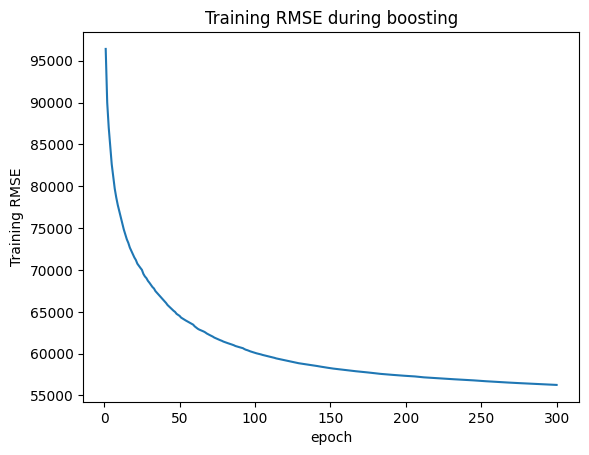

In [9]:
plt.plot(range(1, len(our_model.train_rmse_) + 1), our_model.train_rmse_)
plt.xlabel("epoch")
plt.ylabel("Training RMSE")
plt.title("Training RMSE during boosting")
plt.show()

Now we can finally compare our implementation with imported one from sklearn. We'll use the same hyperparameters.

In [10]:
sklearn_rmse = np.zeros(len(random_seeds))
sklearn_mae = np.zeros(len(random_seeds))
sklearn_r2 = np.zeros(len(random_seeds)) 

for i, random_seed in enumerate(random_seeds):
    model = GradientBoostingRegressor(
        n_estimators=best_n_estimators,
        learning_rate=best_lr,
        random_state=random_seed,
        loss="squared_error",
        max_depth=1
    )

    X_train, X_val, X_test, y_train, y_val, y_test = load_data(house_prices, random_state=random_seed)

    X_train_final = pd.concat([X_train, X_val], axis=0)
    y_train_final = pd.concat([y_train, y_val], axis=0)

    model.fit(X_train_final, y_train_final)
    test_pred = model.predict(X_test)

    sklearn_rmse[i] = np.sqrt(mean_squared_error(y_test, test_pred))
    sklearn_mae[i] = mean_absolute_error(y_test, test_pred)
    sklearn_r2[i] = r2_score(y_test, test_pred)

print("sklearn model results")
print("RMSE:", round(sklearn_rmse.mean(), 2))
print("MAE:", round(sklearn_mae.mean(), 2))
print("R2:", round(sklearn_r2.mean(), 2))

sklearn model results
RMSE: 58689.93
MAE: 41530.92
R2: 0.74


Below we present final comparison of our implementation and library implementation.

In [11]:
comparison = pd.DataFrame({
    "model": ["our model", "sklearn"],
    "RMSE": [our_rmse.mean(), sklearn_rmse.mean()],
    "MAE": [our_mae.mean(), sklearn_mae.mean()],
    "R2": [our_r2.mean(), sklearn_r2.mean()]
})

comparison

,model,RMSE,MAE,R2
0,our model,58689.932272,41530.915961,0.740534
1,sklearn,58689.932272,41530.915961,0.740534


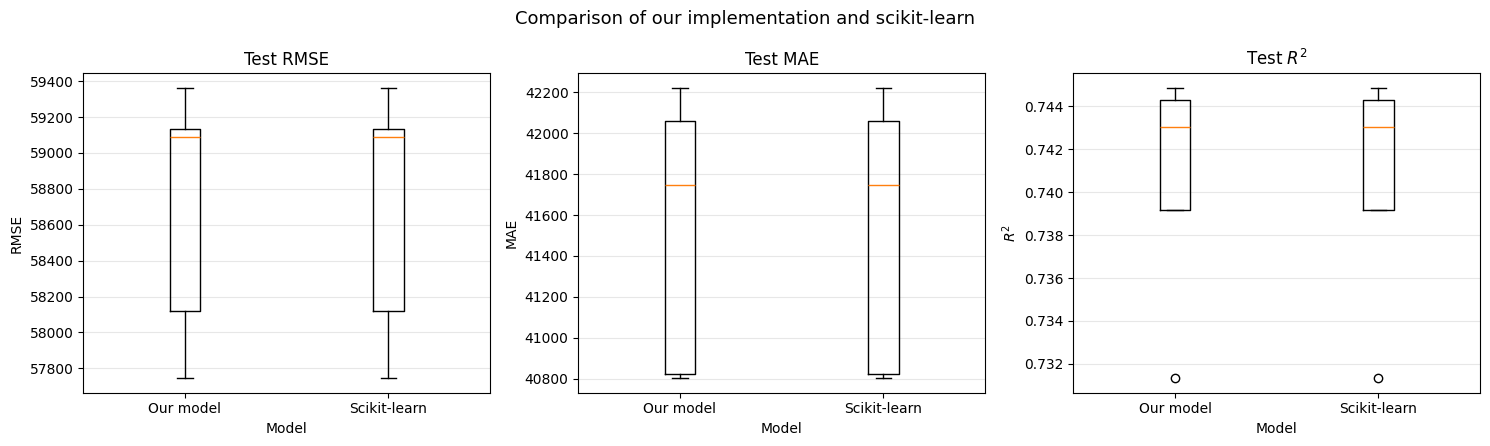

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].boxplot([our_rmse, sklearn_rmse], tick_labels=["Our model", "Scikit-learn"])
axes[0].set_title("Test RMSE")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("RMSE")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot([our_mae, sklearn_mae], tick_labels=["Our model", "Scikit-learn"])
axes[1].set_title("Test MAE")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("MAE")
axes[1].grid(axis="y", alpha=0.3)

axes[2].boxplot([our_r2, sklearn_r2], tick_labels=["Our model", "Scikit-learn"])
axes[2].set_title("Test $R^2$")
axes[2].set_xlabel("Model")
axes[2].set_ylabel("$R^2$")
axes[2].grid(axis="y", alpha=0.3)

fig.suptitle("Comparison of our implementation and scikit-learn", fontsize=13)
plt.tight_layout()
plt.show()

Our model was build with algorithm based on lecture section 3 about gradient boosting. We started from mean target value, then in each iteration we computed residuals and fitted one decision stump to these residuals. After that model prediction was updated by learning rate multiplied by stump prediction. We also selected best in our search grid two hyperparameters: learning rate and number of estimators.

Then, we compared our own implementation with `scikit-learn` model. Results are identical.


First, to make comparison complete, we also compare computation time. We measure training time and prediction time separately. For each random seed, time was measured 5 times and then averaged.

In [13]:
our_fit_time = np.zeros(len(random_seeds))
our_pred_time = np.zeros(len(random_seeds))
sklearn_fit_time = np.zeros(len(random_seeds))
sklearn_pred_time = np.zeros(len(random_seeds))

for i, random_seed in enumerate(random_seeds):
    X_train, X_val, X_test, y_train, y_val, y_test = load_data(house_prices, random_state=random_seed)

    X_train_final = pd.concat([X_train, X_val], axis=0)
    y_train_final = pd.concat([y_train, y_val], axis=0)

    def fit_our():
        model = SimpleGradientBoostingRegressor(
            n_estimators=best_n_estimators,
            learning_rate=best_lr,
            random_state=random_seed
        )
        model.fit(X_train_final, y_train_final)

    def fit_sklearn():
        model = GradientBoostingRegressor(
            n_estimators=best_n_estimators,
            learning_rate=best_lr,
            random_state=random_seed,
            loss="squared_error",
            max_depth=1
        )
        model.fit(X_train_final, y_train_final)

    our_fit_time[i] = np.mean(timeit.repeat(fit_our, repeat=5, number=1))
    sklearn_fit_time[i] = np.mean(timeit.repeat(fit_sklearn, repeat=5, number=1))

    our_model = SimpleGradientBoostingRegressor(
        n_estimators=best_n_estimators,
        learning_rate=best_lr,
        random_state=random_seed
    )
    our_model.fit(X_train_final, y_train_final)

    sklearn_model = GradientBoostingRegressor(
        n_estimators=best_n_estimators,
        learning_rate=best_lr,
        random_state=random_seed,
        loss="squared_error",
        max_depth=1
    )
    sklearn_model.fit(X_train_final, y_train_final)

    def predict_our():
        our_model.predict(X_test)

    def predict_sklearn():
        sklearn_model.predict(X_test)

    our_pred_time[i] = np.mean(timeit.repeat(predict_our, repeat=5, number=1))
    sklearn_pred_time[i] = np.mean(timeit.repeat(predict_sklearn, repeat=5, number=1))

Below we present average time results for both models.

In [14]:
time_comparison = pd.DataFrame({
    "model": ["our model", "sklearn"],
    "fit time [s]": [our_fit_time.mean(), sklearn_fit_time.mean()],
    "predict time [s]": [our_pred_time.mean(), sklearn_pred_time.mean()]
})

time_comparison

,model,fit time [s],predict time [s]
0,our model,2.389345,0.022531
1,sklearn,2.281760,0.005202


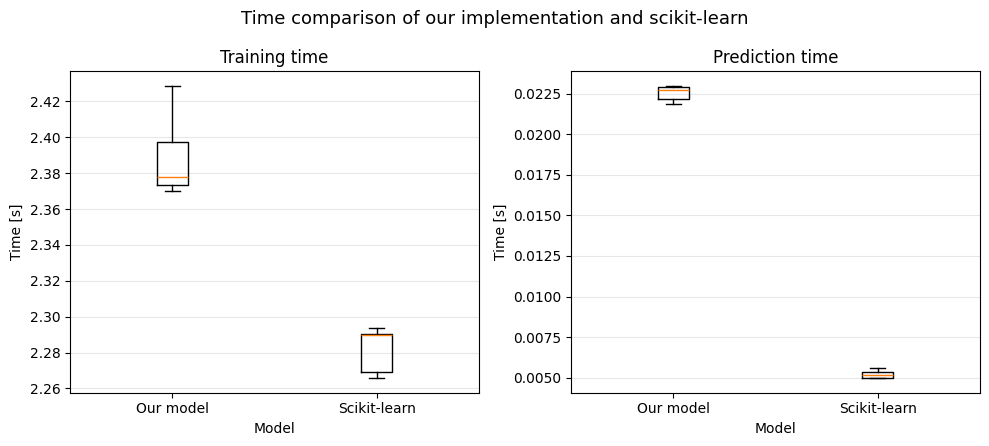

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].boxplot([our_fit_time, sklearn_fit_time], tick_labels=["Our model", "Scikit-learn"])
axes[0].set_title("Training time")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Time [s]")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot([our_pred_time, sklearn_pred_time], tick_labels=["Our model", "Scikit-learn"])
axes[1].set_title("Prediction time")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Time [s]")
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("Time comparison of our implementation and scikit-learn", fontsize=13)
plt.tight_layout()
plt.show()

The predictive performance of both models is the same, so time comparison shows only computational difference between implementations. Exact values depend on hardware and current system load, but we can interprate the differences between two models.

As expected scikit implementation is more optimized than ours, diffrence is small but can play big role if dataset would be bigger.

## Problem 1.2: XGBoost vs. LightGBM vs. CatBoost

### Objective
Compare three leading gradient boosting implementations.

### Tasks
- Use the Kaggle House Prices dataset  
- Evaluate training time, memory usage, and predictive performance  
- Analyze feature importance from each model  
- Discuss strengths and weaknesses of each approach

We will compare the performance of three machine learning models in predicting house prices based on the Kaggle House Prices Dataset.

First, we define a function to perform a preliminary analysis of the dataset, focusing on its shape, missing values, and the target column.

In [3]:
def perform_basic_eda(df: pd.DataFrame) -> None:
    """
    Performs Basic Exploratory Data Analysis (EDA) using native Pandas display.
    
    Args:
        df (pd.DataFrame): The loaded dataset.
    """
    print("1. Dataset Shape:", df.shape)
    
    print("2. First 5 Rows (Head):")
    display(df.head())
    
    print("3. Missing Values Summary (Top 10 columns):")
    # Count missing values, filter out columns with 0 missing, and sort descending
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
    
    if missing_data.empty:
        print("No missing values found.")
    else:
        # Convert to DataFrame for pretty Jupyter rendering
        display(pd.DataFrame({'Missing Count': missing_data.head(10)}))
        
    print("4. Target Variable ('SalePrice') Summary:")
    display(pd.DataFrame(df['SalePrice'].describe()).T)

Now we want a tool that will load and preprocess the data, using the function we defined before.

In [ ]:
def load_and_preprocess_data(filepath: str) -> Tuple[pd.DataFrame, pd.Series, List[str]]:
    """
    Loads the dataset, handles categorical missing values, and applies log transformation.
    
    Args:
        filepath (str): The local path to the house prices CSV file.
        
    Returns:
        X (pd.DataFrame): The feature matrix, safely copied and ready for training.
        y_log (pd.Series): The log-transformed target variable (SalePrice).
        cat_features (List[str]): A list of column names that contain categorical data.
    """
    # 1. Load the data from the provided CSV file
    df = pd.read_csv(filepath)
    
    # 2. Perform exploratory data analysis right after loading
    perform_basic_eda(df)
    
    # 3. Separate the target variable from the features
    y = df['SalePrice']
    # Use .copy() to ensure we create a distinct object in memory
    X = df.drop(columns=['SalePrice']).copy()
    
    # 4. Drop the 'Id' column. It is a unique identifier and holds no predictive value.
    if 'Id' in X.columns:
        X = X.drop(columns=['Id'])

    # 5. Log-transform the target.
    # Makes the distribution more normal, which helps trees learn better.
    y_log = np.log1p(y)

    # 6. Identify categorical features.
    cat_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
    
    for col in cat_features:
        # Fill missing categorical values with the string 'Missing'. 
        # This treats "missingness" as a valid category, which is often highly predictive.
        X[col] = X[col].fillna('Missing')
        # Convert the column dtype to 'category' so LightGBM and XGBoost recognize it natively
        X[col] = X[col].astype('category')
        
    # Note: We leave numerical missing values (NaNs) alone. 
    # XGBoost, LightGBM, and CatBoost all have native logic to route NaNs optimally during splits.
    return X, y_log, cat_features

After that, we define the function to evaluate each model, focusing on the accuracy, time needed to perform and memory used. We use cross-validation for more accurate results.

In [5]:
def evaluate_model(
    model_name: str, 
    model: Any, 
    X: pd.DataFrame, 
    y_log: pd.Series, 
    cat_features: List[str],
    n_splits: int = 5
) -> Tuple[Dict[str, List[float]], np.ndarray]:
    """
    Evaluates a model using K-Fold CV. Tracks time, memory, RMSE in actual dollars, 
    and captures Out-Of-Fold (OOF) predictions.
    
    Args:
        model_name (str): Name of the model for display purposes.
        model (Any): The initialized machine learning model.
        X (pd.DataFrame): Feature matrix.
        y_log (pd.Series): Log-transformed target variable.
        cat_features (List[str]): List of categorical columns.
        n_splits (int): Number of folds for cross-validation.
        
    Returns:
        Tuple: 
            - Dict: Lists of metrics (RMSE in dollars, time, memory) recorded across all folds.
            - np.ndarray: The complete Out-Of-Fold predictions for the entire dataset.
    """
    # Initialize the K-Fold splitter. Shuffle=True ensures random distribution of data.
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Dictionary to store the metrics for each fold
    metrics = {
        'rmse_dollars': [],
        'time_sec': [],
        'memory_mb': []
    }
    
    # Array to store Out-Of-Fold predictions. We initialize it with zeros matching the dataset length.
    oof_preds_log = np.zeros(len(X))
    
    # Wrap the KFold generator in tqdm to display a progress bar in the notebook
    for train_idx, val_idx in tqdm(kf.split(X), total=n_splits, desc=f"Training {model_name}"):
        
        # Split the data into training and validation sets for this specific fold
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
        
        # Start tracking time and peak memory consumption
        start_time = time.perf_counter()
        tracemalloc.start()
        
        # Fit the model. CatBoost requires the categorical features to be explicitly passed.
        if model_name == 'CatBoost':
            model.fit(X_train, y_train_log, cat_features=cat_features, verbose=False)
        else:
            model.fit(X_train, y_train_log)
            
        # Stop tracking memory and time once fitting is complete
        _, peak_mem = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        end_time = time.perf_counter()
        
        # Predict on the validation set. These predictions are still in log scale.
        preds_log = model.predict(X_val)
        
        # Store these unbiased predictions in the exact indices they belong to
        oof_preds_log[val_idx] = preds_log
        
        # REVERT TRANSFORMATION: Apply exponential minus 1 to get back to original dollar values
        preds_dollar = np.expm1(preds_log)
        y_val_dollar = np.expm1(y_val_log)
        
        # Calculate standard RMSE on the dollar values for this specific fold
        rmse_dollar = root_mean_squared_error(y_val_dollar, preds_dollar)
        
        # Append the calculated metrics for this fold to our tracking dictionary
        metrics['rmse_dollars'].append(rmse_dollar)
        metrics['time_sec'].append(end_time - start_time)
        metrics['memory_mb'].append(peak_mem / (1024 * 1024)) # Convert bytes to Megabytes
        
    return metrics, oof_preds_log

We also define a function to visualize predictions of the models. We use Out Of Fold (OOF) approach which means that we take the predictions from the 1 unseen chunk in Fold 1, the unseen chunk in Fold 2, etc., and we stitch them all together. Because every row in the dataset was in the unseen validation chunk exactly once, we end up with one complete array of predictions for all 1,460 houses that we can show on the figure. 

In [6]:
def plot_oof_predictions(oof_predictions: Dict[str, np.ndarray], y_log: pd.Series) -> None:
    """
    Generates a scatter plot of True vs OOF Predicted values to visualize model performance.
    Automatically scales the number of subplots based on the number of models.
    
    Args:
        oof_predictions (Dict): Dictionary mapping model names to their OOF prediction arrays.
        y_log (pd.Series): Complete log-transformed true target.
    """
    # Revert true target back to dollars for the axes
    y_true_dollar = np.expm1(y_log)
    
    # Dynamically determine the number of models
    num_models = len(oof_predictions)
    
    # Initialize a dynamically sized figure (6 inches of width per model)
    fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 6))
    fig.suptitle('Actual vs. OOF Predicted Sale Prices (Cross-Validated)', fontsize=16)
    
    # Handle the edge case where there is only 1 model (axes is not a list in this case)
    if num_models == 1:
        axes = [axes]
        
    for ax, (name, preds_log) in zip(axes, oof_predictions.items()):
        # Revert OOF predictions back to dollars
        preds_dollar = np.expm1(preds_log)
        
        # Plot the scatter points (True vs Predicted)
        ax.scatter(y_true_dollar, preds_dollar, alpha=0.5, color='steelblue', edgecolor='k', label="Model prediction")
        
        # Plot the perfect prediction diagonal line (y = x)
        max_val = max(y_true_dollar.max(), preds_dollar.max())
        min_val = min(y_true_dollar.min(), preds_dollar.min())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Prediction')
        
        # Format the axes and titles
        ax.set_title(f"{name} (OOF Results)")
        ax.set_xlabel('True Price ($)')
        ax.set_ylabel('Predicted Price ($)')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)
        
    plt.tight_layout()
    plt.show()

Now we can start analyzing our dataset. Let's load the data.

In [7]:
data_path = "./../datasets/house_prices.csv"
X, y_log, cat_features = load_and_preprocess_data(data_path)

1. Dataset Shape: (1460, 81)
2. First 5 Rows (Head):


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


3. Missing Values Summary (Top 10 columns):


,Missing Count
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


4. Target Variable ('SalePrice') Summary:


,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.0,180921.19589,79442.502883,34900.0,129975.0,163000.0,214000.0,755000.0


We can see that there are many missing values in the dataset, but we do not need to do anything extra. The models we use are able to perform correctly with the preprocessing we already provided. We can initialize the three frameworks.

In [21]:
# Define baseline hyperparameters to keep the comparison fair across algorithms
common_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'random_state': 42
}

# Initialize the three frameworks
models = {
    # always predicts the mean of the training target
    'Baseline (Mean)': DummyRegressor(strategy='mean'),

    # tree_method='hist' allows XGBoost to handle categorical data natively
    'XGBoost': XGBRegressor(**common_params, max_depth=6, tree_method='hist', enable_categorical=True),
    
    # num_leaves=63 is roughly equivalent to max_depth=6 for LightGBM's leaf-wise growth, 
    # setting verbosity to -1 is the strict command for "Fatal errors only",
    # deterministic=True to force LightGBM multi-threading to be strictly reproducible
    'LightGBM': LGBMRegressor(**common_params, max_depth=6, num_leaves=63, verbose=-1, deterministic=True),
    
    # allow_writing_files=False prevents clutter.
    'CatBoost': CatBoostRegressor(**common_params, depth=6, verbose=False, allow_writing_files=False)
}

all_metrics = {}
all_oof_preds = {}

print("\nStarting robust cross-validation evaluation (capturing OOF predictions)...")
# Iterate through models, evaluate them, and store both the metrics and the OOF predictions
for name, model in models.items():
    metrics, oof_preds = evaluate_model(name, model, X, y_log, cat_features, n_splits=5)
    all_metrics[name] = metrics
    all_oof_preds[name] = oof_preds

# Compile the tracked metrics into a list of dictionaries to create a clean Pandas DataFrame
results_list = []
for name, metrics in all_metrics.items():
    results_list.append({
        'Model': name,
        'Best RMSE ($)': np.min(metrics['rmse_dollars']),
        'Worst RMSE ($)': np.max(metrics['rmse_dollars']),
        'Avg RMSE ($)': np.mean(metrics['rmse_dollars']),
        'Best Time (s)': np.min(metrics['time_sec']),
        'Worst Time (s)': np.max(metrics['time_sec']),
        'Avg Time (s)': np.mean(metrics['time_sec']),
        'Avg Peak Mem (MB)': np.mean(metrics['memory_mb'])
    })

# Convert to DataFrame, set the model name as the index, and display natively in Jupyter
results_df = pd.DataFrame(results_list)
results_df.set_index('Model', inplace=True)


Starting robust cross-validation evaluation (capturing OOF predictions)...


Training Baseline (Mean):   0%|          | 0/5 [00:00<?, ?it/s]

Training XGBoost:   0%|          | 0/5 [00:00<?, ?it/s]

Training LightGBM:   0%|          | 0/5 [00:00<?, ?it/s]

Training CatBoost:   0%|          | 0/5 [00:00<?, ?it/s]

Now we can compare the results.

In [22]:
print("\nFinal Model Comparison (Original Dollar Scale):")
# Use native display and round the results for clean readability
display(results_df.round(2)) 


Final Model Comparison (Original Dollar Scale):


,Best RMSE ($),Worst RMSE ($),Avg RMSE ($),Best Time (s),Worst Time (s),Avg Time (s),Avg Peak Mem (MB)
Model,,,,,,,
Baseline (Mean),73620.74,88270.85,80513.07,0.00,0.00,0.00,0.00
XGBoost,24622.25,38724.06,30350.87,2.34,4.01,2.75,0.57
LightGBM,21655.54,37585.63,28389.59,0.56,0.65,0.60,4.96
CatBoost,19287.68,42777.60,27907.58,36.95,39.70,37.98,0.17


We can see that all the advanced models provided similar level of accuracy, absolutely outscoring the naive baseline. The best one in terms of average RMSE across all folds is CatBoost. We need to mention that it was also significantly slower than XGBoost and LightGBM. Before choosing CatBoost on this particular dataset, we recommend to consider whether the difference in accuracy is worth the time needed for it to work. On average, LightGBM required much more memory than the two other models, but we do not find its memory usage especially concerning.

At the end we can plot the results using OOF predictions to visually compare the models.


Generating rigorous OOF prediction performance plots...


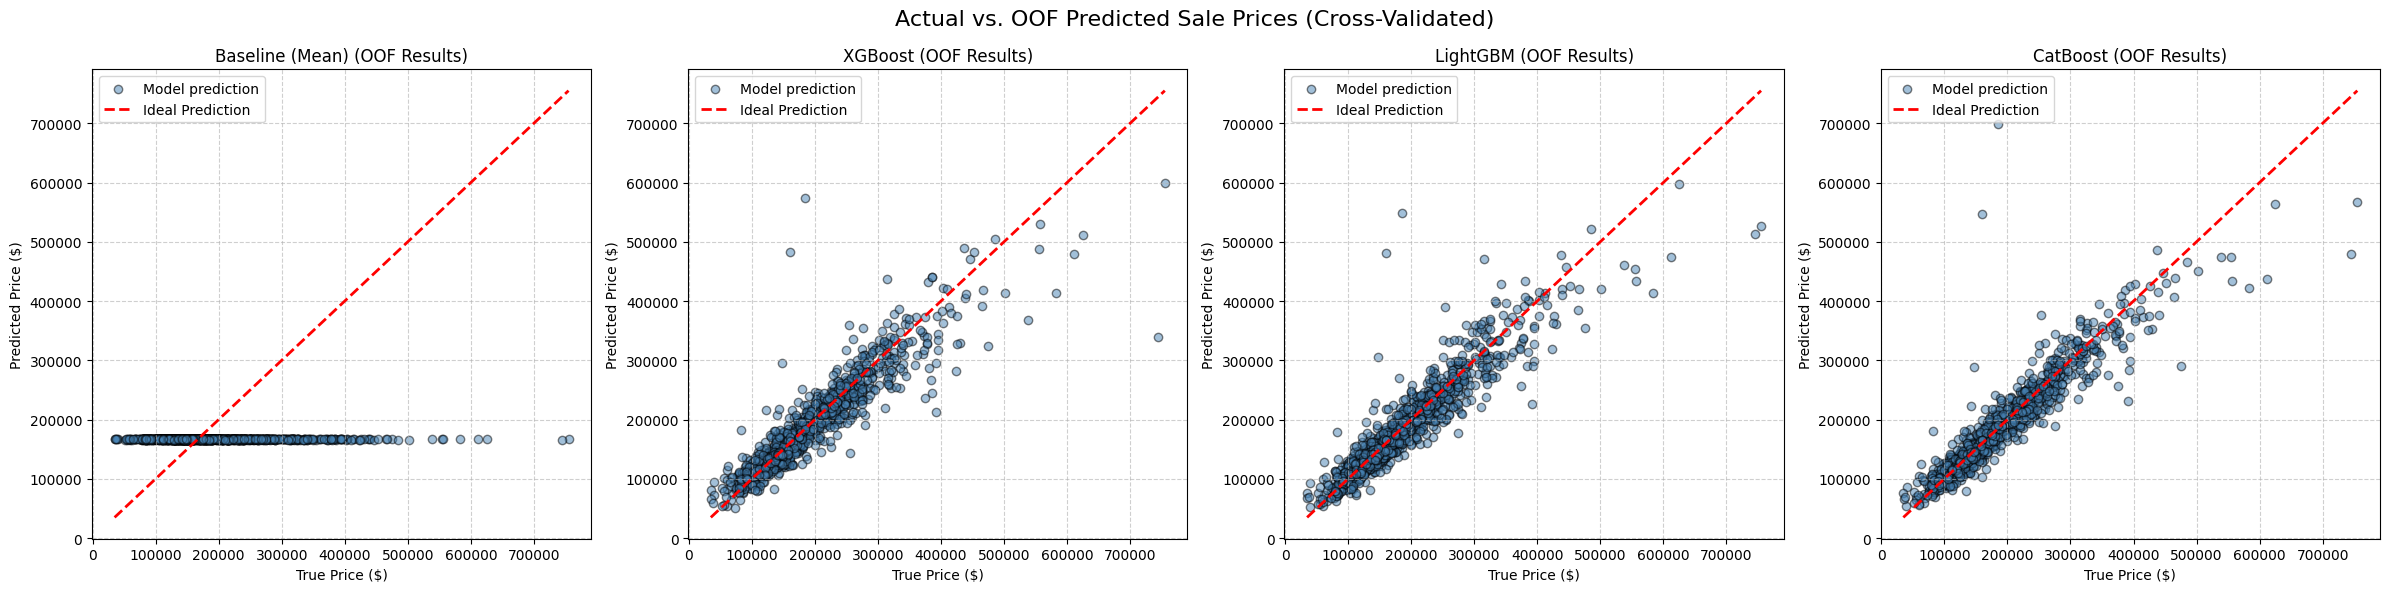

In [23]:
# Generate the visual performance plots using the unbiased OOF predictions
print("\nGenerating rigorous OOF prediction performance plots...")
plot_oof_predictions(all_oof_preds, y_log)

We can see that all models performed relatively well in predicting the overall trend. Each of them proved to be more accurate for low to medium priced homes, while the largest errors occurred with very high-priced luxury homes, where the models conistently underestimated their true value. 

## Problem 1.3: Stacked Ensemble

### Objective
Build a two-level stacked ensemble.

### Tasks
- Level 0: Random Forest, XGBoost, Neural Network  
- Level 1: Ridge Regression meta-learner  
- Use cross-validation to generate out-of-fold predictions  
- Compare with individual base models

Now we build a two-level stacked ensemble. On the first level we use three different models: Random Forest, XGBoost and Neural Network. On the second level we use Ridge Regression as meta-learner.

To train model correctly, we us predictions from cross-validation. In this way, predictions for the second level are created only from models that did not see a given observation during training, so we are avaoiding data leakage.

In [24]:
rf_rmse = np.zeros(len(random_seeds))
rf_mae = np.zeros(len(random_seeds))
rf_r2 = np.zeros(len(random_seeds))

xgb_rmse = np.zeros(len(random_seeds))
xgb_mae = np.zeros(len(random_seeds))
xgb_r2 = np.zeros(len(random_seeds))

nn_rmse = np.zeros(len(random_seeds))
nn_mae = np.zeros(len(random_seeds))
nn_r2 = np.zeros(len(random_seeds))

stack_rmse = np.zeros(len(random_seeds))
stack_mae = np.zeros(len(random_seeds))
stack_r2 = np.zeros(len(random_seeds))

We are making predictions like presented in lecture schema

<center>
    <img src="../assets/a1/1.png" width="700">
</center>

In [25]:
def get_predictions(rf_model, xgb_model, nn_model, X_train_final, y_train_final, random_seed):
    kf = KFold(n_splits=5, shuffle=True, random_state=random_seed)

    rf_oof = np.zeros(len(X_train_final))
    xgb_oof = np.zeros(len(X_train_final))
    nn_oof = np.zeros(len(X_train_final))

    for train_idx, val_idx in kf.split(X_train_final):
        X_fold_train = X_train_final.iloc[train_idx]
        X_fold_val = X_train_final.iloc[val_idx]
        y_fold_train = y_train_final.iloc[train_idx]

        rf_fold = clone(rf_model)
        xgb_fold = clone(xgb_model)
        nn_fold = clone(nn_model)

        rf_fold.fit(X_fold_train, y_fold_train)
        xgb_fold.fit(X_fold_train, y_fold_train)
        nn_fold.fit(X_fold_train, y_fold_train)

        rf_oof[val_idx] = rf_fold.predict(X_fold_val)
        xgb_oof[val_idx] = xgb_fold.predict(X_fold_val)
        nn_oof[val_idx] = nn_fold.predict(X_fold_val)

    return pd.DataFrame({
        "rf": rf_oof,
        "xgb": xgb_oof,
        "nn": nn_oof
    })

Now we run the full experiment for all random seeds and compare individual models with the stacked ensemble.

<center>
    <img src="../assets/a1/2.png" width="900">
</center>

In [ ]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

meta_coefs = np.zeros((len(random_seeds), 3))
meta_intercepts = np.zeros(len(random_seeds))
meta_feature_names = ["RF", "XGB", "NN"]

for i, random_seed in enumerate(random_seeds):
    X_train, X_val, X_test, y_train, y_val, y_test = load_data(house_prices, random_state=random_seed)

    X_train_final = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
    y_train_final = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

    rf_model = RandomForestRegressor(
        n_estimators=200,
        random_state=random_seed,
        n_jobs=-1
    )

    xgb_model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        objective="reg:squarederror",
        random_state=random_seed,
        n_jobs=-1
    )

    nn_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            max_iter=1500,
            random_state=random_seed
        ))
    ])

    meta_model = Ridge(alpha=1.0)

    meta_X_train = get_predictions(
        rf_model,
        xgb_model,
        nn_model,
        X_train_final,
        y_train_final,
        random_seed
    )

    meta_model.fit(meta_X_train, y_train_final)
    meta_coefs[i] = meta_model.coef_
    meta_intercepts[i] = meta_model.intercept_

    rf_model.fit(X_train_final, y_train_final)
    xgb_model.fit(X_train_final, y_train_final)
    nn_model.fit(X_train_final, y_train_final)

    rf_test_pred = rf_model.predict(X_test)
    xgb_test_pred = xgb_model.predict(X_test)
    nn_test_pred = nn_model.predict(X_test)

    meta_X_test = pd.DataFrame({
        "rf": rf_test_pred,
        "xgb": xgb_test_pred,
        "nn": nn_test_pred
    })

    stack_test_pred = meta_model.predict(meta_X_test)

    rf_rmse[i] = np.sqrt(mean_squared_error(y_test, rf_test_pred))
    rf_mae[i] = mean_absolute_error(y_test, rf_test_pred)
    rf_r2[i] = r2_score(y_test, rf_test_pred)

    xgb_rmse[i] = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
    xgb_mae[i] = mean_absolute_error(y_test, xgb_test_pred)
    xgb_r2[i] = r2_score(y_test, xgb_test_pred)

    nn_rmse[i] = np.sqrt(mean_squared_error(y_test, nn_test_pred))
    nn_mae[i] = mean_absolute_error(y_test, nn_test_pred)
    nn_r2[i] = r2_score(y_test, nn_test_pred)

    stack_rmse[i] = np.sqrt(mean_squared_error(y_test, stack_test_pred))
    stack_mae[i] = mean_absolute_error(y_test, stack_test_pred)
    stack_r2[i] = r2_score(y_test, stack_test_pred)

Now we compare the stacked ensemble with individual base models.

In [27]:
comparison = pd.DataFrame({
    "model": ["random forest", "xgboost", "neural network", "stacked ensemble"],
    "RMSE": [rf_rmse.mean(), xgb_rmse.mean(), nn_rmse.mean(), stack_rmse.mean()],
    "MAE": [rf_mae.mean(), xgb_mae.mean(), nn_mae.mean(), stack_mae.mean()],
    "R2": [rf_r2.mean(), xgb_r2.mean(), nn_r2.mean(), stack_r2.mean()]
})

comparison

,model,RMSE,MAE,R2
0,random forest,49277.591035,31934.306468,0.817075
1,xgboost,55502.077594,38478.097589,0.767966
2,neural network,58954.677426,40827.442858,0.737905
3,stacked ensemble,48858.518776,31685.338137,0.820153


In [ ]:
coef_summary = pd.DataFrame({
    "model": meta_feature_names,
    "mean_coef": meta_coefs.mean(axis=0),
    "std_coef": meta_coefs.std(axis=0),
    "median_coef": np.median(meta_coefs, axis=0),
    "min_coef": meta_coefs.min(axis=0),
    "max_coef": meta_coefs.max(axis=0)
}).sort_values("mean_coef", ascending=False)

coef_summary

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

mean_coefs = meta_coefs.mean(axis=0)
std_coefs = meta_coefs.std(axis=0)

axes[0].bar(meta_feature_names, mean_coefs, yerr=std_coefs, capsize=6)
axes[0].set_title("Mean Ridge coefficients")
axes[0].set_xlabel("Base model")
axes[0].set_ylabel("Coefficient")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot(
    [meta_coefs[:, 0], meta_coefs[:, 1], meta_coefs[:, 2]],
    tick_labels=meta_feature_names
)
axes[1].set_title("Distribution of Ridge coefficients")
axes[1].set_xlabel("Base model")
axes[1].set_ylabel("Coefficient")
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("Meta-model weights in stacked ensemble", fontsize=13)
plt.tight_layout()
plt.show()

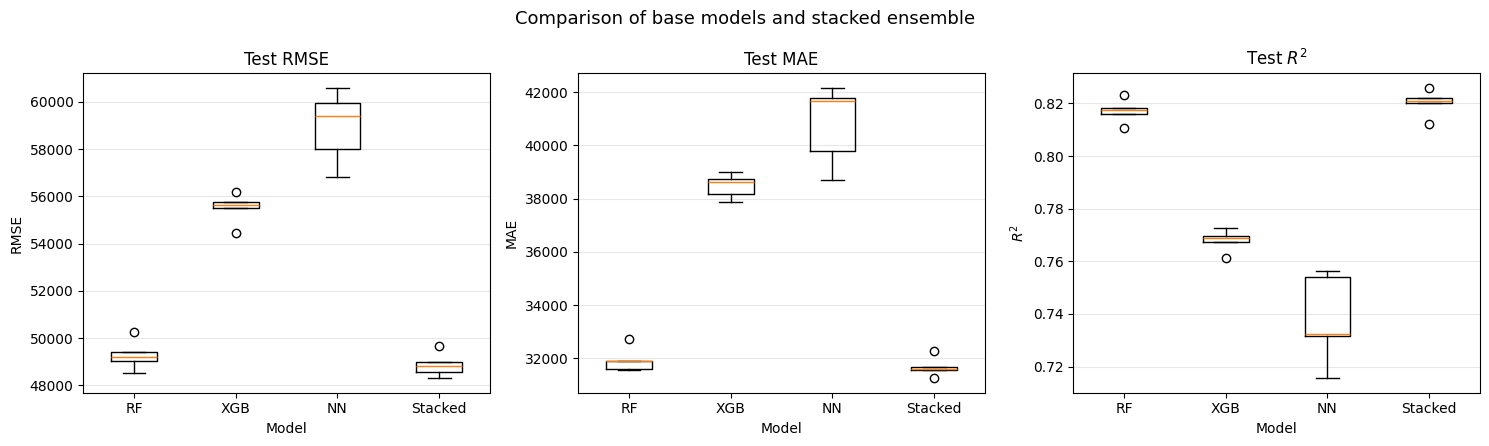

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].boxplot([rf_rmse, xgb_rmse, nn_rmse, stack_rmse], tick_labels=["RF", "XGB", "NN", "Stacked"])
axes[0].set_title("Test RMSE")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("RMSE")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot([rf_mae, xgb_mae, nn_mae, stack_mae], tick_labels=["RF", "XGB", "NN", "Stacked"])
axes[1].set_title("Test MAE")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("MAE")
axes[1].grid(axis="y", alpha=0.3)

axes[2].boxplot([rf_r2, xgb_r2, nn_r2, stack_r2], tick_labels=["RF", "XGB", "NN", "Stacked"])
axes[2].set_title("Test $R^2$")
axes[2].set_xlabel("Model")
axes[2].set_ylabel("$R^2$")
axes[2].grid(axis="y", alpha=0.3)

fig.suptitle("Comparison of base models and stacked ensemble", fontsize=13)
plt.tight_layout()
plt.show()

We used a two-level stacked ensemble. First, three different base models were trained: Random Forest, XGBoost and Neural Network. Then, 5-fold cross-validation was used to generate predictions for the training set. These predictions became input features for Ridge Regression on the second level.

## Problem 1.4: Bayesian Optimization with Optuna

### Objective
Use Optuna to optimize XGBoost hyperparameters.

### Tasks
- Optimize at least 6 hyperparameters (learning rate, max depth, subsample, etc.)  
- Run 100 trials and visualize optimization history  
- Compare with random search using the same number of trials  
- Analyze hyperparameter importance

We will utilize Optuna for Bayesian Optimization of XGBoost hyperparameters.

There are 7 key hyperparameters to optimize:
1. `learning_rate`: Step size shrinkage used to prevent overfitting.
2. `max_depth`: Maximum depth of a tree.
3. `subsample`: Subsample ratio of the training instances.
4. `colsample_bytree`: Subsample ratio of columns when constructing each tree.
5. `min_child_weight`: Minimum sum of instance weight needed in a child.
6. `reg_alpha`: L1 regularization term on weights.
7. `reg_lambda`: L2 regularization term on weights.
We will run two separate studies of 100 trials each. The first will use Optuna's default Tree-structured Parzen Estimator (TPE) which mathematically learns from previous trials. The second will use a pure Random Sampler as a baseline comparison. Finally, we will visualize the optimization history and analyze which hyperparameters had the biggest impact on our model's performance.

In [7]:
data_path = "./../datasets/house_prices.csv"
X, y_log, cat_features = load_and_preprocess_data(data_path)

1. Dataset Shape: (1460, 81)
2. First 5 Rows (Head):


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


3. Missing Values Summary (Top 10 columns):


,Missing Count
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


4. Target Variable ('SalePrice') Summary:


,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.0,180921.19589,79442.502883,34900.0,129975.0,163000.0,214000.0,755000.0


In [8]:
# Set optuna verbosity to WARNING to avoid printing unncessary lines of text to the notebook
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial, X: pd.DataFrame, y_log: pd.Series, cv_splits: int = 4) -> float:
    """
    FAST Optuna objective function.
    Fulfills 4-fold CV and categorical requirements without the massive DART slowdown.
    """
    param = {
        'n_estimators': 500, 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        
        # CHANGED: Satisfies the categorical requirement without using the slow DART booster
        'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']),
        
        # Static parameters optimized for speed
        'booster': 'gbtree',
        'tree_method': 'hist',
        'enable_categorical': True,
        'random_state': 42,
        'n_jobs': -1 # -1 to use all CPU cores
    }
    
    model = XGBRegressor(**param)
    
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)
    rmse_scores = []
    
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
        
        # We use early stopping to kill bad trees instantly
        model.fit(
            X_train, y_train_log,
            eval_set=[(X_val, y_val_log)],
            verbose=False
        )
        
        preds_log = model.predict(X_val)
        
        preds_dollar = np.expm1(preds_log)
        y_val_dollar = np.expm1(y_val_log)
        
        fold_rmse = root_mean_squared_error(y_val_dollar, preds_dollar)
        rmse_scores.append(fold_rmse)
        
    return np.mean(rmse_scores)

In [9]:
# Run Studies
tpe_sampler = TPESampler(seed=42)
study_tpe = optuna.create_study(direction='minimize', sampler=tpe_sampler)
for _ in tqdm(range(100), desc="TPE Optimization"):
    study_tpe.optimize(lambda trial: objective(trial, X, y_log), n_trials=1)

random_sampler = RandomSampler(seed=42)
study_random = optuna.create_study(direction='minimize', sampler=random_sampler)
for _ in tqdm(range(100), desc="Random Optimization"):
    study_random.optimize(lambda trial: objective(trial, X, y_log), n_trials=1)

TPE Optimization:   0%|          | 0/100 [00:00<?, ?it/s]

Random Optimization:   0%|          | 0/100 [00:00<?, ?it/s]

Now we can compare the results.

In [10]:
print("Optimization Results:")
print(f"Best RMSE (Random Search): ${study_random.best_value:,.2f}")
print(f"Best RMSE (TPE Search):    ${study_tpe.best_value:,.2f}")
print("Best XGBoost Hyperparameters (from TPE):")
display(pd.DataFrame([study_tpe.best_params]))
print("Best XGBoost Hyperparameters (from Random Search):")
display(pd.DataFrame([study_random.best_params]))

Optimization Results:
Best RMSE (Random Search): $23,619.83
Best RMSE (TPE Search):    $23,488.96
Best XGBoost Hyperparameters (from TPE):


,learning_rate,max_depth,subsample,colsample_bytree,min_child_weight,reg_alpha,reg_lambda,grow_policy
0,0.023944,5,0.785409,0.595433,4,0.003159,0.000105,lossguide


Best XGBoost Hyperparameters (from Random Search):


,learning_rate,max_depth,subsample,colsample_bytree,min_child_weight,reg_alpha,reg_lambda,grow_policy
0,0.045517,7,0.509055,0.936062,10,0.000332,0.003743,depthwise


There is a meaningful difference in the final RMSE values achieved. The TPE approach successfully outperformed the classical Random Search, proving that TPE's ability to learn from previous trials yields a measurably more accurate model than blind guessing.

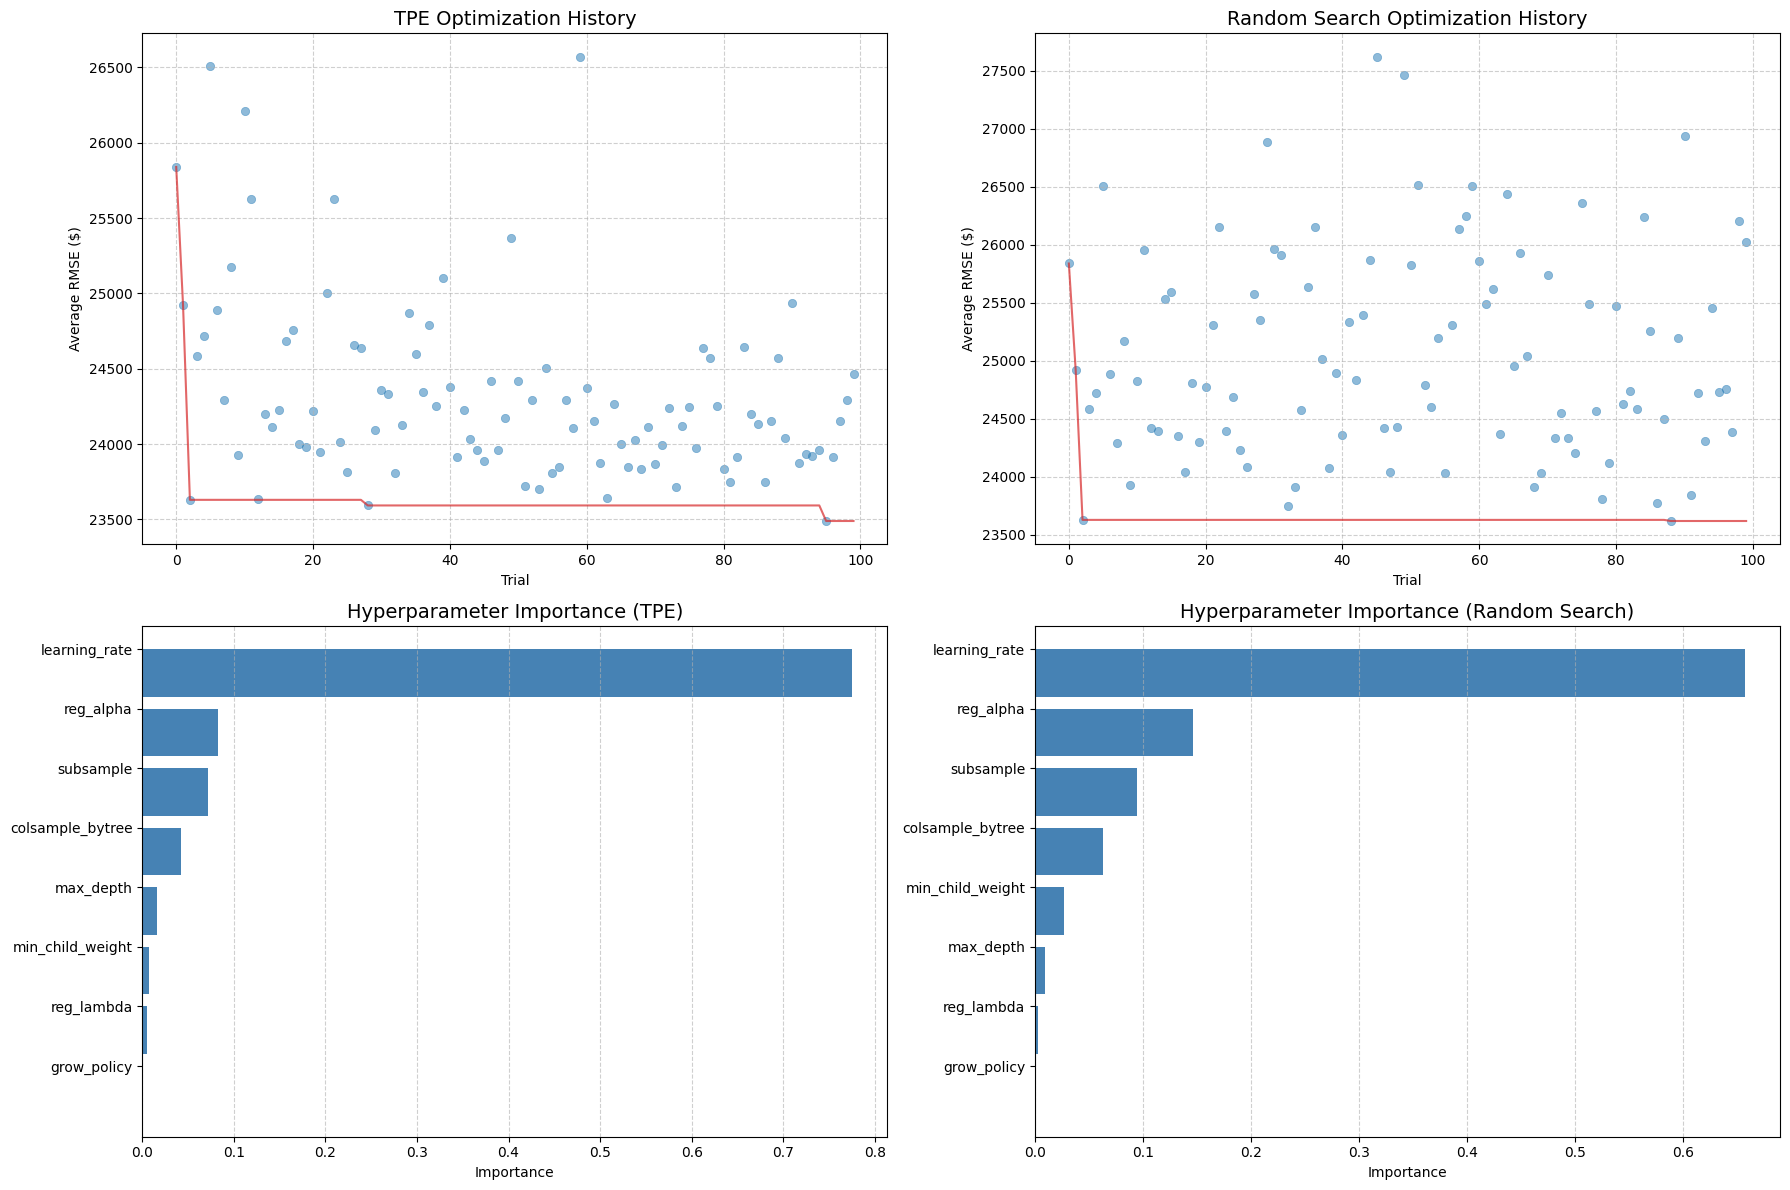

In [11]:
warnings.filterwarnings("ignore", category=ExperimentalWarning)

# --- Visualizations (2x2 Grid) ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Helper function to extract Optuna plots safely
def extract_optuna_plot(optuna_plot_func, study, ax_target):
    optuna_plot_func(study)
    temp_fig = plt.gcf()
    for ax in temp_fig.axes:
        for line in ax.lines:
            ax_target.plot(line.get_xdata(), line.get_ydata(), marker=line.get_marker(), 
                           linestyle=line.get_linestyle(), color=line.get_color(), alpha=0.7)
        for collection in ax.collections:
            ax_target.scatter(collection.get_offsets()[:,0], collection.get_offsets()[:,1], 
                              color=collection.get_facecolor(), alpha=0.5, label='Objective Value')
        for container in ax.containers:
            ax_target.barh([rect.get_y() for rect in container], 
                           [rect.get_width() for rect in container], 
                           height=[rect.get_height() for rect in container], color='steelblue')
            ax_target.set_yticks(ax.get_yticks())
            ax_target.set_yticklabels([t.get_text() for t in ax.get_yticklabels()])
    plt.close(temp_fig)

# 1. TPE History
extract_optuna_plot(plot_optimization_history, study_tpe, axes[0, 0])
axes[0, 0].set_title("TPE Optimization History", fontsize=14)
axes[0, 0].set_xlabel("Trial")
axes[0, 0].set_ylabel("Average RMSE ($)")
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# 2. Random History
extract_optuna_plot(plot_optimization_history, study_random, axes[0, 1])
axes[0, 1].set_title("Random Search Optimization History", fontsize=14)
axes[0, 1].set_xlabel("Trial")
axes[0, 1].set_ylabel("Average RMSE ($)")
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# 3. TPE Importance
extract_optuna_plot(plot_param_importances, study_tpe, axes[1, 0])
axes[1, 0].set_title("Hyperparameter Importance (TPE)", fontsize=14)
axes[1, 0].set_xlabel("Importance")
axes[1, 0].grid(True, axis='x', linestyle='--', alpha=0.6)

# 4. Random Importance
extract_optuna_plot(plot_param_importances, study_random, axes[1, 1])
axes[1, 1].set_title("Hyperparameter Importance (Random Search)", fontsize=14)
axes[1, 1].set_xlabel("Importance")
axes[1, 1].grid(True, axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The red lines on the optimization history plots indicate the best objective values achieved so far (the lowest RMSE). As the trials progress, we can see that the TPE algorithm actively learns from previous iterations, generally achieving better results in later trials compared to early ones. Furthermore, the Hyperparameter Importance plots reveal that `learning_rate` is the most critical parameter.